
# YouTube Video Data Analysis: Complete Step-by-Step Guide
## A Comprehensive Data Cleaning and Data Analysis Workflow

This notebook provides a complete walkthrough of analyzing trending video data, covering:
1. Data loading and cleaning
2. Feature engineering
3. Exploratory data analysis
4. Statistical testing
5. Country-specific insights

**Dataset**: There are two dataset provided: *USvideos.csv* and *GBvideos.csv*


## Step 1: Environment Setup (complete one step in this step)
First, we'll import all necessary libraries and configure our environment. You might need the following packages:
1. numpy
2. pandas
3. matplotlib.pyplot
4. seaborn (as sns)
5. glob
6. datetime
7. scipy

Configuration packages/settings:

9. %matplotlib inline (IPython magic command)
10. sns.set() (Seaborn configuration)
11. pd.set_option() (Pandas display options)

In [ ]:
# step 1: import all modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob 
import datetime
import scipy


# Configuration
%matplotlib inline
sns.set(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.options.mode.chained_assignment = None

print("Environment setup complete!")

Environment setup complete!


## Step 2: Data Loading (complete two steps in this step)
We'll load all US videos CSV files and GB videos; and combine them into a single dataframe with country identifiers.

In [42]:
# step 1: read all csv files into list and assign to csv_files
csv_files = glob.glob('*.csv')
print(f"Found {len(csv_files)} CSV files") 

# Load each CSV with country code
dataframes = [] 

# step 2: read csv files into dataframe and append dataframe into dataframes
for file in csv_files:
    # Extract country code from filename and assign t country_code
    country_code = file[:2]
    print(country_code)
    # read file to dataframe
    df = pd.read_csv(file) 
    # adding a new column to the DataFrame (df) that identifies the country
    df['country'] = country_code
    dataframes.append(df)
    
# Verify loading
print("\nSample data from first dataframe:")
display(dataframes[0].head(2))

print(dataframes[0].columns.tolist())

Found 2 CSV files
US
GB

Sample data from first dataframe:


,video_id,title,channel_title,category_id,tags,views,likes,dislikes,comment_total,thumbnail_link,date,country
0,XpVt6Z1Gjjo,1 YEAR OF VLOGGING -- HOW LOGAN PAUL CHANGED Y...,Logan Paul Vlogs,24,logan paul vlog|logan paul|logan|paul|olympics...,4394029,320053,5931,46245,https://i.ytimg.com/vi/XpVt6Z1Gjjo/default.jpg,NaN,US
1,K4wEI5zhHB0,iPhone X — Introducing iPhone X — Apple,Apple,28,Apple|iPhone 10|iPhone Ten|iPhone|Portrait Lig...,7860119,185853,26679,0,https://i.ytimg.com/vi/K4wEI5zhHB0/default.jpg,NaN,US


['video_id', 'title', 'channel_title', 'category_id', 'tags', 'views', 'likes', 'dislikes', 'comment_total', 'thumbnail_link', 'date', 'country']


## Step 3: Data Cleaning (complete one function in this step)
We'll clean and standardize data types across all dataframes.

In [43]:

"""
Step 1: define a function clean_dataframe takes a dataframe parameter. 
        the function will convert columns : ['video_id', 'title', 'channel_title', 'category_id', 'tags', 'thumbnail_link']
        into string, and handling missing Tags
"""  
def clean_dataframe(df):
    """Clean and standardize a single dataframe"""
    str_col = ['video_id', 'title', 'channel_title', 'category_id', 'tags', 'thumbnail_link']
    for col_name in str_col: 
       df[col_name] = df[col_name].astype('string')

    return df





# Clean all dataframes
cleaned_dataframes = [clean_dataframe(df) for df in dataframes]

# Verify cleaning
print("\nData types after cleaning:")
display(cleaned_dataframes[0].dtypes)



Data types after cleaning:


video_id           string
title              string
channel_title      string
category_id        string
tags               string
views               int64
likes               int64
dislikes            int64
comment_total       int64
thumbnail_link     string
date              float64
country               str
dtype: object

## Step 4: Missing Value Analysis (complete one function in this step)
We'll identify and handle any missing values in our dataset.

In [44]:
"""
Step 1: define a function analyze_missing_data
        the function returns a missing report that contains country code, missing count and missing percent
        
"""

def analyze_missing_data(df_list, country_codes):
    """Analyze missing values across all dataframes"""
    rows = []
    for df, code in zip (df_list, country_codes):

        missing_count = df.isna().sum().sum()
        total_count   = df.shape[0] * df.shape[1]
        missing_percent = round((missing_count)/total_count * 100,2) if total_count > 0 else 0

        rows.append({
            "country_code" : code, 
            "missing_count": missing_count,
            "missing_percent": missing_percent
        })
    #print(rows)
    return pd.DataFrame(rows)

    
    


    

# defines a list contains all conuntry code.
country_codes = [filename[0:2] for filename in csv_files]

missing_report = analyze_missing_data(cleaned_dataframes, country_codes)



# Display results
print("Missing value summary:")
print(missing_report[missing_report['missing_count'] > 0])
display(missing_report[missing_report['missing_count'] > 0])


Missing value summary:
  country_code  missing_count  missing_percent
0           US           7998             8.33
1           GB             33             0.03


,country_code,missing_count,missing_percent
0,US,7998,8.33
1,GB,33,0.03


## Step 5: Data Integration (complete five steps in this step)
Combine all country dataframes into one unified dataset.

In [70]:
# Step 1: Combine all dataframes
combined_df = pd.concat(cleaned_dataframes, ignore_index=True)



# Step 2: Create backup before deduplication
backup = combined_df

# Step 3: Remove duplicate videos (keeping first occurrence) by video_id
combined_df = combined_df.drop_duplicates()

# Step 4: Set video_id as index
#combined_df = combined_df.set_index('video_id')



# Final dataset info
print("\nCombined dataset information:")
print(f"Total videos: {len(combined_df)}")
print(f"Countries: {combined_df['country'].unique().tolist()}")



Combined dataset information:
Total videos: 15985
Countries: ['US', 'GB']


## Step 6: Feature Engineering (complete six steps in this step)
Create new features to enhance our analysis.

In [77]:
# Engagement metrics
# Step 1: add a column named 'like_ratio', computed as likes/dislikes
#------- complete the step-------------
combined_df['like_ratio']  = combined_df['likes']/combined_df['dislikes']

#------- complete the step-------------

# Step 2: add a column named 'engagement_rate', computed as (likes + dislikes + comment_total)/views
#------- complete the step-------------

combined_df['engagement_rate']  = (combined_df['likes']+combined_df['dislikes']+combined_df['comment_total'])/combined_df['views']
#------- complete the step-------------


# Text features
# Step 3: add a column named 'title_length', computed as length of title
#------- complete the step-------------
combined_df['title_length'] = combined_df['title'].str.len()

#------- complete the step-------------

# Step 4: add a column named 'title_word_count', computed as number of words in title
combined_df['title_word_count'] = combined_df['title'].str.split().str.len()



# Step 5: add a column named 'title_has_exclamation', computed as bool value (you can make it 0 or 1) of if title contains exclamation mark
combined_df['title_has_exclamation'] = (combined_df['title'].str.contains('!')).astype(int)


# Tag analysis
# Step 6: add a column named 'tags_count', computed as number of tags 
combined_df['tags_count'] = combined_df['tags'].str.split('|').str.len()


# Display new features
print("\nNew features created:")
display(combined_df[['like_ratio', 'engagement_rate', 
                    'title_length', 'tags_count', 'views']].describe())
print((combined_df['views'] == 0).sum())

print(combined_df.shape)


New features created:


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,like_ratio,engagement_rate,title_length,tags_count,views
count,1.581200e+04,1.594100e+04,15985.0,15985.000000,1.598500e+04
mean,inf,inf,47.905099,18.355271,1.025275e+06
std,NaN,NaN,19.14392,12.272824,2.638581e+06
min,0.000000e+00,0.000000e+00,7.0,1.000000,0.000000e+00
25%,1.616655e+01,1.845755e-02,34.0,8.000000,1.035380e+05
50%,3.682693e+01,3.786631e-02,46.0,17.000000,3.121960e+05
75%,7.307589e+01,5.913819e-02,59.0,27.000000,9.665530e+05
max,inf,inf,100.0,70.000000,5.896141e+07


12
(15985, 18)


## Step 7: Exploratory Data Analysis (complete two steps in this step)
Now we'll explore our dataset through visualizations and summary statistics.

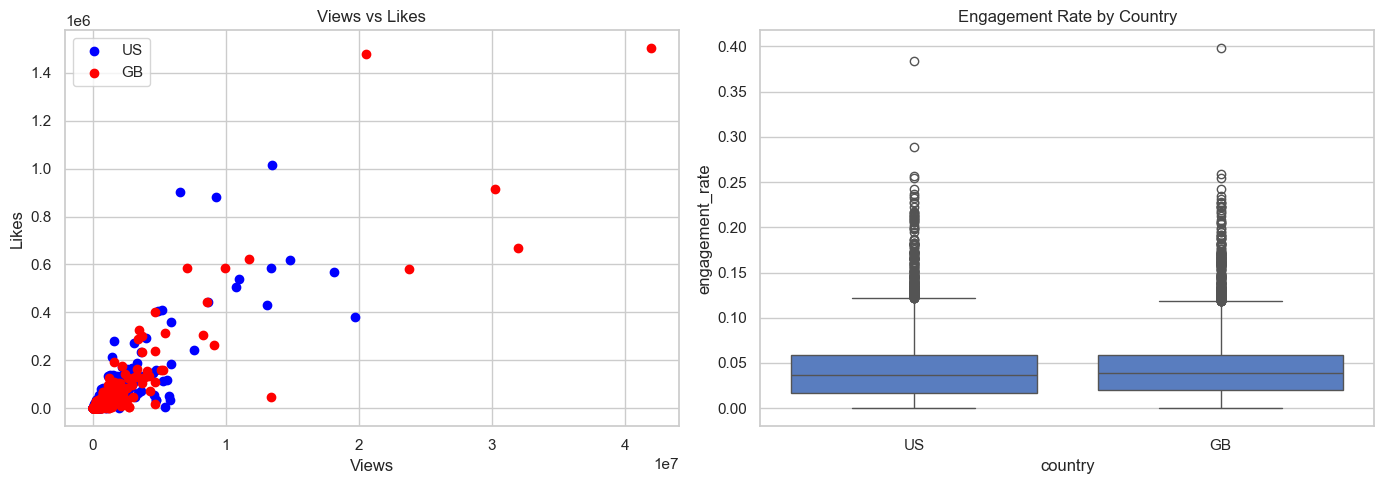

In [72]:
# Set up the figure
fig, ax = plt.subplots(1,2, figsize=(14,5))
        

# Plot 1: Views vs. Likes
# Step 1: make a dot plot shows views and likes. Take 1000 sample from all countries. x-axis will be views and y-axies will be views.
#         using different colors indicate different country. Add legend and plot title.

'''take random 1000 rows of df
    filter us or gb
    add views and likes series of each country to scatter plot, 
        if country is gb, color is red, if us, color is blue

'''

sample = combined_df.sample(1000)

usSample = sample[sample['country'] == 'US']
gbSample = sample[sample['country'] == 'GB']
ax[0].scatter(usSample['views'], usSample['likes'], color='blue', label='US')
ax[0].scatter(gbSample['views'], gbSample['likes'], color='red', label='GB')
ax[0].set_xlabel('Views')
ax[0].set_ylabel('Likes')
ax[0].set_title('Views vs Likes')
ax[0].legend()

# Plot 2: Engagement Rate by Country
# Step 2: make a box plot shows different country engagement_rate


sns.boxplot(data=combined_df, x='country', y='engagement_rate', ax=ax[1])
ax[1].set_title('Engagement Rate by Country')












plt.tight_layout()
plt.show()

In [85]:
print(combined_df['views'].unique())
print(len(combined_df['views'].unique()))

[4394029 7860119 5845909 ...  170003  893125 1474925]
15274


## Step 8: Country-Specific Analysis (complete one function in this step)
We'll examine trends and patterns for individual countries.

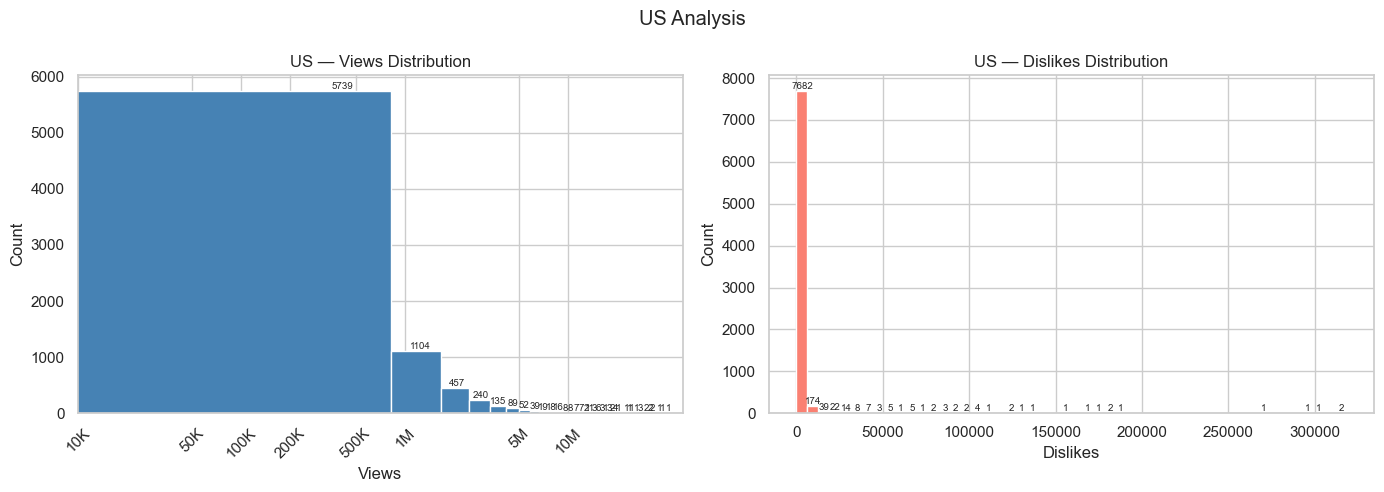

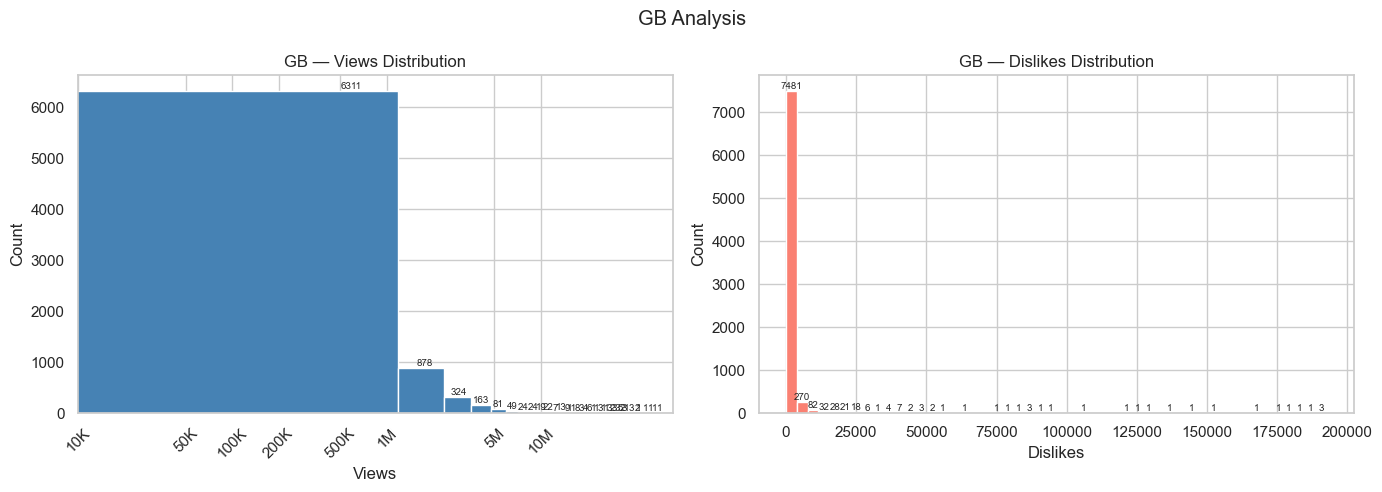

In [86]:
def analyze_country(df, country_code):
    """Generate country-specific analysis"""
    country_df = df[df['country'] == country_code]

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{country_code} Analysis')

    # Bar plot 1: Views distribution
    counts, bins, patches = ax[0].hist(country_df['views'].dropna(), bins=50, color='steelblue', edgecolor='white')
    ax[0].set_title(f'{country_code} — Views Distribution')
    ax[0].set_xlabel('Views')
    ax[0].set_ylabel('Count')
    ax[0].set_xscale('log')
    ax[0].set_xticks([10000, 50000, 100000, 200000, 500000, 1000000, 5000000, 10000000])
    ax[0].set_xticklabels(['10K', '50K', '100K', '200K', '500K', '1M', '5M', '10M'], rotation=45)
    # Add count on top of each bar
    for count, patch in zip(counts, patches):
        if count > 0:  # only label bars that have values
            ax[0].text(patch.get_x() + patch.get_width()/2, count, 
                      int(count), ha='center', va='bottom', fontsize=7)

    # Bar plot 2: Dislikes distribution
    counts, bins, patches = ax[1].hist(country_df['dislikes'].dropna(), bins=50, color='salmon', edgecolor='white')
    ax[1].set_title(f'{country_code} — Dislikes Distribution')
    ax[1].set_xlabel('Dislikes')
    ax[1].set_ylabel('Count')
    # Add count on top of each bar
    for count, patch in zip(counts, patches):
        if count > 0:
            ax[1].text(patch.get_x() + patch.get_width()/2, count,
                      int(count), ha='center', va='bottom', fontsize=7)

    plt.tight_layout()
    plt.show()

for country in ['US', 'GB']:
    analyze_country(combined_df, country)

## Step 9: Advanced Insights (complete one step in this step)
We'll extract deeper insights through more sophisticated analysis.

In [ ]:
# Step 1: can you think of a analysis and visualize it?
# Videos have more views have a tendency to have more dislikes


## Step 10: Saving Results
Finally, we'll save our cleaned data and visualizations.

In [ ]:
# Step 1: Save cleaned data into csv file
combined_df.to_csv('cleaned_youtube_trending_data.csv')


print("Saved cleaned data to 'cleaned_youtube_trending_data.csv'")

# Step 2: Save top 5 globa category bar plot visualizations


print("Saved visualization to 'top_categories.png'")



Saved cleaned data to 'cleaned_youtube_trending_data.csv'
Saved visualization to 'top_categories.png'
